<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

Mecânica dos Sólidos I

# I.1 Conceito de tensão. Vector tensão. Tensão normal e tangencial. Equações de equilíbrio e tensor das tensões.

## Problema 5 <a name="PI15"></a>

Considere o seguinte estado de tensão (kPa):

\begin{equation*}
\begin{aligned}
\sigma_{xx} &= (1-x^2)y + 2y^3/3; \quad
\sigma_{yy} = - (y^3 -12y)/3; \quad
\sigma_{zz} = (3-x^2)y \quad \\
\sigma_{xy} &= - (4-y^2)x; \quad
\sigma_{yz} = 0; \quad \sigma_{xz} = 0.
\end{aligned}
\end{equation*}

a) Verifique se, na ausência de forças mássicas ($b_i$), o campo de tensões satisfaz as equações de equilíbrio.

b) Determine o vector tensão no ponto $p(x, y, z) \equiv p(2 ; -1 ; 6)$, aplicado no plano de equação $3x+6y+2z = 12$.

## Resolução


findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


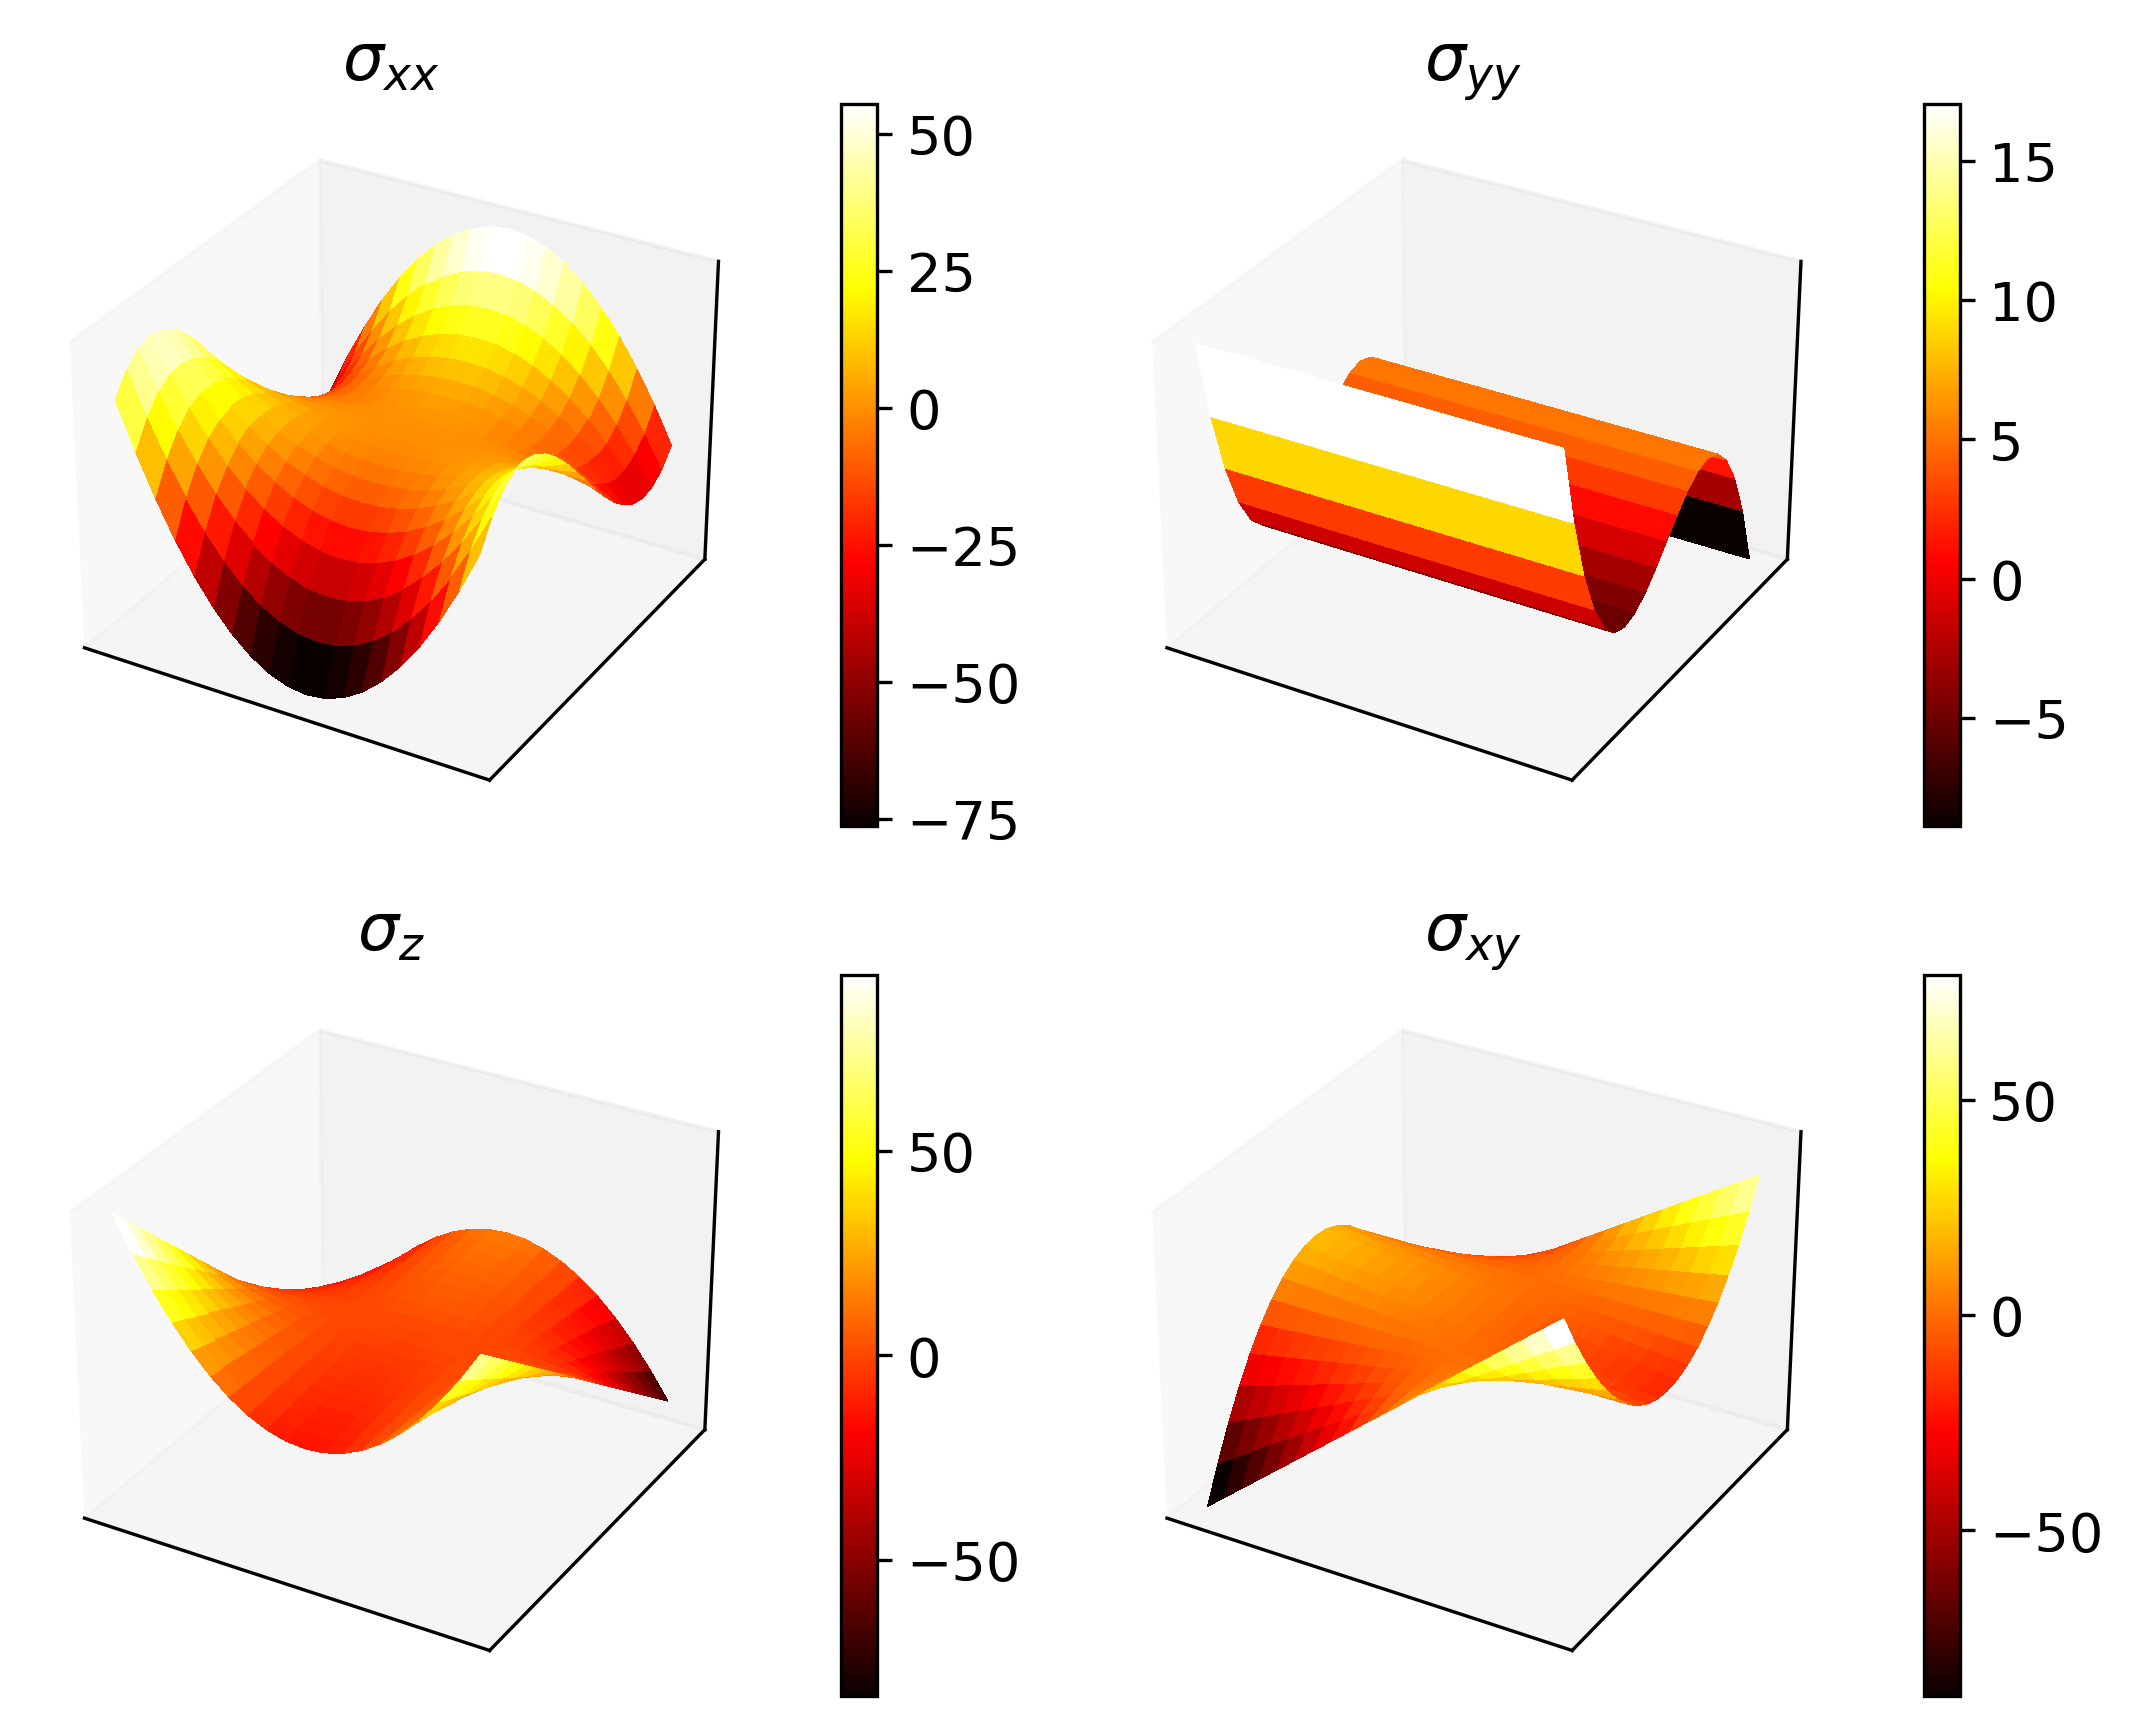

In [1]:
% matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, diff
from pylab import cm, title

x, y, z, Sxx, Syy, Szz, Sxy, Syx, Syz, Szy, Sxz, Szx = symbols('x y z Sxx Syy Szz Sxy Syx Syz Szy Sxz Szx')

def Sxx(x, y): return (1 - x ** 2) * y + 2 * y ** 3 / 3
def Syy(x, y): return - (y ** 3 - 12 * y) / 3
def Szz(x, y): return (3 - x ** 2) * y
def Sxy(x, y): return - (4 - y ** 2) * x
def Syx(x, y): return Sxy(x, y)
# sigma_ij = sigma_ji - simetria do tensor das tensões
def Syz(x, y): return 0
def Szy(x, y): return Syz(x, y)
def Sxz(x, y): return 0
def Szx(x, y): return Sxz(x, y)

xa = np.arange(-5.0, 5.0, .5)
ya = np.arange(-5.0, 5.0, .5)
Xa, Ya = np.meshgrid(xa, ya)  # grid of point

# fig = plt.figure(111)
# ax1 = fig.add_subplot(111, projection='3d')
# cset = ax1.plot_surface(Xa,Ya, Sxx(Xa,Ya), cmap=cm.hot)
# plt.title(r'$\sigma_{xx}$')
# plt.show()
#
# fig = plt.figure(111)
# ax2 = fig.add_subplot(111, projection='3d')
# cset = ax2.plot_surface(Xa,Ya, Syy(Xa,Ya), cmap=cm.hot)
# plt.title(r'$\sigma_{yy}$')
# plt.show()
#
# fig = plt.figure(111)
# ax2 = fig.add_subplot(111, projection='3d')
# cset = ax2.plot_surface(Xa,Ya, Szz(Xa,Ya), cmap=cm.hot)
# plt.title(r'$\sigma_{zz}$')
# plt.show()
#
# fig = plt.figure(111)
# ax2 = fig.add_subplot(111, projection='3d')
# cset = ax2.plot_surface(Xa,Ya, Sxy(Xa,Ya), cmap=cm.hot)
# plt.title(r'$\sigma_{xy}$')
# plt.show()

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import

font = {'family': 'normal', 'size': 13}
plt.rc('font', **font)

# set up a figure twice as wide as it is tall
fig = plt.figure(figsize=(10, 6), dpi=300)

#  1st subplot -  set up the axes for the first plot
ax = fig.add_subplot(2, 2, 1, projection='3d')
surf = ax.plot_surface(Xa, Ya, Sxx(Xa, Ya), rstride=1, cstride=1, cmap=cm.hot,
                       linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=1., aspect=20)
plt.title(r'$\sigma_{xx}$')
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

# 2n subplot - set up the axes for the second plot
ax = fig.add_subplot(2, 2, 2, projection='3d')
surf = ax.plot_surface(Xa, Ya, Syy(Xa, Ya), rstride=1, cstride=1, cmap=cm.hot,
                       linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=1., aspect=20)
plt.title(r'$\sigma_{yy}$')
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

# 3rd subplot - set up the axes for the second plot
ax = fig.add_subplot(2, 2, 3, projection='3d')
surf = ax.plot_surface(Xa, Ya, Szz(Xa, Ya), rstride=1, cstride=1, cmap=cm.hot,
                       linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=1., aspect=20)
plt.title(r'$\sigma_{z}$')
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

# 4th subplot - set up the axes for the second plot
ax = fig.add_subplot(2, 2, 4, projection='3d')
surf = ax.plot_surface(Xa, Ya, Sxy(Xa, Ya), rstride=1, cstride=1, cmap=cm.hot,
                       linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=1., aspect=20)
plt.title(r'$\sigma_{xy}$')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.subplots_adjust(hspace=15)
fig.tight_layout()
plt.show()

#### a) Verifique se, na ausência de forças mássicas ($b_i$), o campo de tensões satisfaz as equações de equilíbrio.

A análise do balanço local do momento linear para um volume infinitesimal em torno de um ponto $P$ permite escrever a seguinte equação de equilíbrio, escrita em forma vetorial:

\begin{equation*}
\frac{\partial\vec{t}(\vec{e}_1) }{\partial x_1} +
\frac{\partial\vec{t}(\vec{e}_2) }{\partial x_2} +
\frac{\partial\vec{t}(\vec{e}_3) }{\partial x_3} +
\vec{f} = \rho \vec{a}
\end{equation*}

ou,

\begin{equation*}
\mathrm{div}\,\tilde{\sigma}^{\,T} +
\vec{f} = \rho \vec{a}
\end{equation*}

cuja representação indicial vem:

\begin{equation*}
\sigma_{ji,j} + f_i  = \rho a_i
\end{equation*}

A equação de balanço local do momento linear em forma matricial vem escrita por:

\begin{equation*}
\frac{\partial}{\partial x_1}
\begin{bmatrix}
\sigma_{11} \\ \sigma_{12} \\ \sigma_{13}
\end{bmatrix} +
\frac{\partial}{\partial x_2}
\begin{bmatrix}
\sigma_{21} \\ \sigma_{22} \\ \sigma_{23}
\end{bmatrix} +
\frac{\partial}{\partial x_3}
\begin{bmatrix}
\sigma_{31} \\ \sigma_{32} \\ \sigma_{33}
\end{bmatrix} +
\begin{bmatrix}
f_{1} \\ f_{2} \\ f_{3}
\end{bmatrix} = \rho
\begin{bmatrix}
a_{1} \\ a_{2} \\ a_{3}
\end{bmatrix}
\end{equation*}

ou

\begin{equation*}
\begin{bmatrix}
\displaystyle\frac{\partial \sigma_{11}}{\partial x_1} +
\displaystyle\frac{\partial \sigma_{21}}{\partial x_2} +
\displaystyle\frac{\partial \sigma_{31}}{\partial x_3} \\
\displaystyle\frac{\partial \sigma_{12}}{\partial x_1} +
\displaystyle\frac{\partial \sigma_{22}}{\partial x_2} +
\displaystyle\frac{\partial \sigma_{32}}{\partial x_3} \\
\displaystyle\frac{\partial \sigma_{13}}{\partial x_1} +
\displaystyle\frac{\partial \sigma_{23}}{\partial x_2} +
\displaystyle\frac{\partial \sigma_{33}}{\partial x_3}
\end{bmatrix} +
\begin{bmatrix}
f_{1} \\ f_{2} \\ f_{3}
\end{bmatrix} = \rho
\begin{bmatrix}
a_{1} \\ a_{2} \\ a_{3}
\end{bmatrix}
\end{equation*}

Na ausência de forças dinâmicas ($a_i = 0$) e desprezando o efeito das forças exteriores de volume ($f_i = 0$), a equação de equilíbrio estabelece:

\begin{equation*}
\sigma_{ji,j} = 0
\end{equation*}

ou em forma matricial no sistema de coordenadas $S(0,x,y,x)$:

\begin{equation*}
\displaystyle\frac{\partial \sigma_{ji}}{\partial x_j} \equiv
\begin{bmatrix}
\displaystyle\frac{\partial \sigma_{xx}}{\partial x} +
\displaystyle\frac{\partial \sigma_{yx}}{\partial y} +
\displaystyle\frac{\partial \sigma_{zx}}{\partial z} \\
\displaystyle\frac{\partial \sigma_{xy}}{\partial x} +
\displaystyle\frac{\partial \sigma_{yy}}{\partial y} +
\displaystyle\frac{\partial \sigma_{zy}}{\partial z} \\
\displaystyle\frac{\partial \sigma_{xz}}{\partial x} +
\displaystyle\frac{\partial \sigma_{yz}}{\partial y} +
\displaystyle\frac{\partial \sigma_{zz}}{\partial z}
\end{bmatrix} =
\begin{bmatrix}
0 \\ 0 \\ 0
\end{bmatrix}
\end{equation*}

A derivadas participais podem ser resolvidas analiticamente, e.g.:

\begin{equation*}
\displaystyle\frac{\partial \sigma_{xx}}{\partial x} =
\displaystyle\frac{\partial }{\partial x}\left[(1-x^2)y + \frac{2y^3}{3}
\right] = -2xy
\end{equation*}

Estas podem também ser obtidas por computação simbólica.

In [2]:
vc1 = diff(Sxx(x, y), x) + diff(Syx(x, y), y) + diff(Szx(x, y), z)
vc2 = diff(Sxy(x, y), x) + diff(Syy(x, y), y) + diff(Szy(x, y), z)
vc3 = diff(Sxz(x, y), x) + diff(Syz(x, y), y) + diff(Szz(x, y), z)

print('div[0] : (', diff(Sxx(x, y), x), ') + (', diff(Syx(x, y), y), ') + (', diff(Szx(x, y), z), ') = 0')
print('div[1] : (', diff(Sxy(x, y), x), ') + (', diff(Syy(x, y), y), ') + (', diff(Szy(x, y), z), ')= 0')
print('div[2] : (', diff(Sxz(x, y), x), ') + (', diff(Syz(x, y), y), ') + (', diff(Szz(x, y), z), ')= 0')
print('div sigma_ij: ', np.array([vc1, vc2, vc3]))
print(' ')
print('R: Pelo que se conclui que o estado de tensão dado')
print('verifica as equações de equilíbrio do sólido ou objeto')

div[0] : ( -2*x*y ) + ( 2*x*y ) + ( 0 ) = 0
div[1] : ( y**2 - 4 ) + ( 4 - y**2 ) + ( 0 )= 0
div[2] : ( 0 ) + ( 0 ) + ( 0 )= 0
div sigma_ij:  [0 0 0]
 
R: Pelo que se conclui que o estado de tensão dado
verifica as equações de equilíbrio do sólido ou objeto


#### b) Determine o vector tensão no ponto $p(x, y, z) \equiv p(2 ; -1 ; 6)$, aplicado no plano de equação $3x+6y+2z = 12$.

O tensor das tensões vem escrita na seguinte forma matricial:

\begin{equation*}
\underline{\underline{\sigma}}^T(P) =
\begin{bmatrix}
(1-x^2)y + 2y^3/3 & -(4-y^2)x & 0 \\
-(4-y^2)x & - (y^3 -12y)/3 & 0  \\
0 & 0 & (3-x^2)y
\end{bmatrix}
\end{equation*}

Para o ponto $P(2 ; -1 ; 6)$ resulta


In [3]:
xP = 2;
yP = -1;
zP = 6

print('code 1: --- ')
Tij = np.array([[Sxx(xP, yP), Sxy(xP, yP), Sxz(xP, yP)],
                [Syx(xP, yP), Syy(xP, yP), Syz(xP, yP)],
                [Szx(xP, yP), Szy(xP, yP), Szz(xP, yP)]])

print('Sij = \n', Tij)

print('code 2: --- ')
s11 = Sxx(x, y);
s12 = Sxy(x, y);
s13 = 0
s21 = Syx(x, y);
s22 = Syy(x, y);
s23 = 0
s31 = 0;
s32 = 0;
s33 = Szz(x, y)

TijSy = np.array([[s11.subs({x: xP, y: yP}), s12.subs({x: xP, y: yP}), s13],
                  [s21.subs({x: xP, y: yP}), s22.subs({x: xP, y: yP}), s23],
                  [s13, s23, s33.subs({x: xP, y: yP})]])

print('Sij = \n', TijSy)

code 1: --- 
Sij = 
 [[ 2.33333333 -6.          0.        ]
 [-6.         -3.66666667  0.        ]
 [ 0.          0.          1.        ]]
code 2: --- 
Sij = 
 [[7/3 -6 0]
 [-6 -11/3 0]
 [0 0 1]]


Da geometria Euclideana, é possível mostrar que se $a$, $b$, $c$ e $d$ forem constantes e, além disso, $a$, $b$, e $c$ forem não nulos, então o gráfico da equação:

\begin{equation*}
ax+by+cz+d=0
\end{equation*}

é um plano com uma orientação perpendicular o vetor $\vec{n} = (a,~b,~c)$.

Considere-se nesta caso a equação escalar do plano dada por:

\begin{equation*}
3x + 6y + 2z = 12
\end{equation*}

Esta equação pode ser manipulada algebricamente de várias formas. Por exemplo, pode-se escrever a equação para a variável dependente $z$:

\begin{equation*}
 z = -\frac{3}{2}x -2y + 6
\end{equation*}

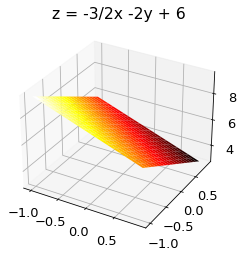

In [4]:
xa = np.arange(-1, 1, .1)
ya = np.arange(-1, 1, .1)
Xa, Ya = np.meshgrid(xa, ya)  # grid of point


def eqplano(x, y):
    return -3 / 2 * x - 2 * y + 6


fig = plt.figure(121)
ax1 = fig.add_subplot(111, projection='3d')
cset = ax1.plot_surface(Xa, Ya, eqplano(Xa, Ya), cmap=cm.hot)
ax1.clabel(cset, fontsize=9, inline=1)
title(r' z = -3/2x -2y + 6');
plt.show()
plt.show()

Um outra forma conveniente de expressar a equação do plano é:

\begin{equation*}
\frac{x}{4} + \frac{y}{2} + \frac{z}{6} - 1 = 0
\end{equation*}

Neste caso os coeficientes de $x,y,z$ as componentes do vetor normal ao plano:
$\vec{n} = (1/4,~1/2,~1/6)$. Este vetor $\vec{n}$ pode ser agora normalizado, pela divisão pela sua norma, para a definição do versor normal ao plano:

\begin{equation*}
\hat{n} = \frac{\vec{n}}{||\vec{n} ||}
\end{equation*}

Da algebra de matrizes, para um vetor genérico, $\vec{v} \equiv v_i,~(i= 1,
\ldots,m)$, a $p$-norma para
vetores é dada por:

\begin{equation*}
||\vec{v}||_p = \left( \sum_{i}^m|v_i|^p\right)^{1/p}
\end{equation*}

Para o caso particular de $p = 2$ a norma vetorial é designada por norma de Frobenius e vem dada por:

\begin{equation*}
||\vec{v}||_2 = (|v_1|^2 + \cdots + |v_m|^2 )^{1/2} = (v^Tv)^{1/2}
\end{equation*}

Pelo que resulta finalmente,

\begin{equation*}
\hat{n} = \frac{\vec{n}}{\sqrt{\vec{n}\cdot\vec{n}}} =
\frac{n_x\vec{\imath}+n_y\vec{\jmath}+n_z\vec{k}}{\sqrt{n_x^2+n_y^2+n_z^2}}
\end{equation*}

In [5]:
def vetor(n1, n2, n3): return np.array([n1, n2, n3])


vecP = vetor(1 / 4, 1 / 2, 1 / 6)
# ou, em alternativa : vecP = vetor(3,6,2)

vecPn2 = np.sqrt(np.dot(vecP, vecP))
# ou: versorn2 = np.sqrt(vecP[0]**2 + vecP[1]**2 + vecP[2]**2)
# ou: np.linalg.norm(vecP)

vetorn = vecP / vecPn2
print('||n||2 = ', vecPn2)
print('n = ', vetorn)

||n||2 =  0.5833333333333334
n =  [0.42857143 0.85714286 0.28571429]


Pela fórmula de Cauchy:


\begin{equation*}
\begin{aligned}
\vec{t}{(P,\vec{n})} &= \tilde\sigma^T(P) \cdot \vec{n}
\quad|\quad \underline{t} (P,\vec{n}) = \underline{\underline{\sigma}}^T(P) \cdot \underline{n}
&\quad\text{(notação direta)} \\
t_i &= \sigma_{ji} \cdot n_j &\quad\text{(notação indicial)}
\end{aligned}
\end{equation*}

In [6]:
print('O vector tensão no ponto P(2;-1;6), aplicado no plano de equação 3x+6y+2z = 12 vem:')

vectensao = np.dot(Tij, vetorn)
print('t^{P,n} [kPa] = ')
print(vectensao)

O vector tensão no ponto P(2;-1;6), aplicado no plano de equação 3x+6y+2z = 12 vem:
t^{P,n} [kPa] = 
[-4.14285714 -5.71428571  0.28571429]


### Apêndice: Equação do plano

Um plano é uma superfície bidimensional, dividida por dois vetores linearmente independentes. Considere o plano representado na figura onde são identificados dois pontos com vetores posição
$\vec{r}_0=(x_0,y_0,z_0)$ e $\vec{r}=(x,y,z)$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au01/Plane.jpg"
width="200" height="200">

A equação do plano definido por um versor normal (não nulo) $\vec{n} = (a,b,c)$ no ponto $\vec{r}_0 = (x_0,y_0,z_0)$ é dada por:

\begin{equation*}
\vec{n}\cdot(\vec{r} - \vec{r}_0) = 0
\quad\Leftrightarrow\quad
\vec{n}\cdot\vec{r} = \vec{n}\cdot\vec{r}_0
\end{equation*}

O produto escalar nulo representa geometricamente a perpendicularidade entre os vetores $\vec{n}$ e $(\vec{x} - \vec{x}_0)$, ou, por outras palavras, entre $\vec{n}$ e o plano. Esta equação é conhecida por equação vetorial do plano.

Desenvolvendo o produto interno resulta:

\begin{equation*}
ax + by  + cz + d = 0
\end{equation*}

em que, $d \equiv -ax_0 -by_0-cz_0 $.

As componentes cartesiandas do versor $\vec{n} \equiv
\hat{n} = (n_x,n_y,n_z)$ são dadas por:

\begin{equation*}
\begin{aligned}
n_x = \frac{a}{\sqrt{a^2+b^2+c^2}}\\
n_y = \frac{b}{\sqrt{a^2+b^2+c^2}}\\
n_z = \frac{c}{\sqrt{a^2+b^2+c^2}}
\end{aligned}
\end{equation*}




**Referências**

[1] <a href="https://mathworld.wolfram.com/Plane.html" target="_blank"> <span
style="color:#333399"> Plane by Mathworld Wolfram </span> </a>

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>





